In [66]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.train_model import load_model
from src.models.predict import predict_2026_champion, calculate_win_probability
from src. visualization.visualize import (
    plot_predictions_2026, plot_comparison_2025_vs_2026,
    plot_interactive_predictions, create_summary_report
)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [67]:
# Load the model we trained in notebook 03
model = load_model("../models/linear_regression_model.pkl")

# Load model metrics
metrics = pd.read_csv("../models/model_metrics.csv").iloc[0]. to_dict()

print("\n✓ Model loaded successfully")
print(f"  Test R²: {metrics['test_r2']:.4f}")
print(f"  Test RMSE: {metrics['test_rmse']:.2f} points")

✓ Model loaded from ../models/linear_regression_model.pkl

✓ Model loaded successfully
  Test R²: 0.9750
  Test RMSE: 14.66 points


In [68]:
# Load all features
all_features = pd.read_csv("../data/processed/driver_features.csv")

# Use 2024 as base year for 2025 predictions
latest_year = 2024
features_2024 = all_features[all_features['Year'] == latest_year].copy()

print(f"✓ Loaded {latest_year} season features")
print(f"  Drivers: {len(features_2024)}")
print(f"  Available years in data: {sorted(all_features['Year'].unique())}")

features_2024.head(10)

✓ Loaded 2024 season features
  Drivers: 24
  Available years in data: [np.int64(2023), np.int64(2024)]


,Year,Driver,Team,TotalRaces,TotalPoints,AvgPoints,StdPoints,AvgFinish,MedianFinish,AvgGrid,Podiums,Wins,PodiumRate,WinRate,DNFs,DNFRate,AvgPositionChange,RollingAvgPoints,RollingPodiumRate,PrevYearPoints,PrevYearPodiums
1,2024,Alexander Albon,Williams,24,12.0,0.500000,1.351328,14.541667,15.0,12.875000,0,0,0.000000,0.000000,0,0.0,-1.666667,18.5,0.000000,25.0,0.0
3,2024,Carlos Sainz,Ferrari,23,262.0,11.391304,6.726739,5.695652,5.0,5.695652,9,2,0.391304,0.086957,0,0.0,0.000000,220.0,0.263834,178.0,3.0
5,2024,Charles Leclerc,Ferrari,24,327.0,13.625000,6.870305,4.541667,3.0,5.416667,13,3,0.541667,0.125000,0,0.0,0.875000,256.0,0.407197,185.0,6.0
7,2024,Daniel Ricciardo,RB,18,7.0,0.388889,1.036901,13.388889,13.0,13.111111,0,0,0.000000,0.000000,0,0.0,-0.277778,6.5,0.000000,6.0,0.0
9,2024,Esteban Ocon,Alpine,23,23.0,1.000000,3.741657,13.695652,14.0,13.434783,1,0,0.043478,0.000000,0,0.0,-0.260870,39.5,0.044466,56.0,1.0
11,2024,Fernando Alonso,Aston Martin,24,70.0,2.916667,3.295803,10.166667,9.0,9.416667,0,0,0.000000,0.000000,0,0.0,-0.750000,134.0,0.181818,198.0,8.0
12,2024,Franco Colapinto,Williams,9,5.0,0.555556,1.333333,13.555556,12.0,16.000000,0,0,0.000000,0.000000,0,0.0,2.444444,5.0,0.000000,0.0,0.0
14,2024,George Russell,Mercedes,24,226.0,9.416667,6.385559,6.750000,5.5,5.625000,4,2,0.166667,0.083333,0,0.0,-1.125000,191.5,0.128788,157.0,2.0
16,2024,Guanyu Zhou,Kick Sauber,24,4.0,0.166667,0.816497,15.500000,15.0,17.583333,0,0,0.000000,0.000000,0,0.0,2.083333,5.0,0.000000,6.0,0.0
17,2024,Jack Doohan,Alpine,1,0.0,0.000000,0.000000,15.000000,15.0,17.000000,0,0,0.000000,0.000000,0,0.0,2.000000,0.0,0.000000,0.0,0.0


In [69]:
# Predict 2026 championship points
predictions_df = predict_2026_champion(model, features_2024)

# Calculate win probabilities
predictions_df = calculate_win_probability(predictions_df)

print(f"✓ Predictions generated for {len(predictions_df)} drivers\n")

# Show top 10
print("="*70)
print("TOP 10 PREDICTED 2026 CHAMPIONSHIP STANDINGS")
print("="*70)
print(predictions_df.head(10).to_string(index=False))

✓ Predictions generated for 24 drivers

TOP 10 PREDICTED 2026 CHAMPIONSHIP STANDINGS
         Driver            Team  Predicted2026Points  PrevYearPoints  PredictedPosition  WinProbability
 Max Verstappen Red Bull Racing           400.443015           399.0                  1       29.894811
   Lando Norris         McLaren           343.307248           344.0                  2       16.883339
Charles Leclerc         Ferrari           328.163888           327.0                  3       14.510807
   Carlos Sainz         Ferrari           276.761863           262.0                  4        8.678714
  Oscar Piastri         McLaren           261.708579           265.0                  5        7.465859
 George Russell        Mercedes           225.574234           226.0                  6        5.201760
 Lewis Hamilton        Mercedes           206.404567           207.0                  7        4.294351
   Sergio Perez Red Bull Racing           139.520911           138.0               

In [70]:
champion = predictions_df.iloc[0]

print("\n" + "🏆"*30)
print(f"\n  PREDICTED 2026 F1 WORLD CHAMPION")
print(f"\n  {champion['Driver']} ({champion['Team']})")
print(f"\n  Predicted Points: {champion['Predicted2026Points']:.1f}")
print(f"  Win Probability: {champion['WinProbability']:.2f}%")
print(f"\n" + "🏆"*30)


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

  PREDICTED 2026 F1 WORLD CHAMPION

  Max Verstappen (Red Bull Racing)

  Predicted Points: 400.4
  Win Probability: 29.89%

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆


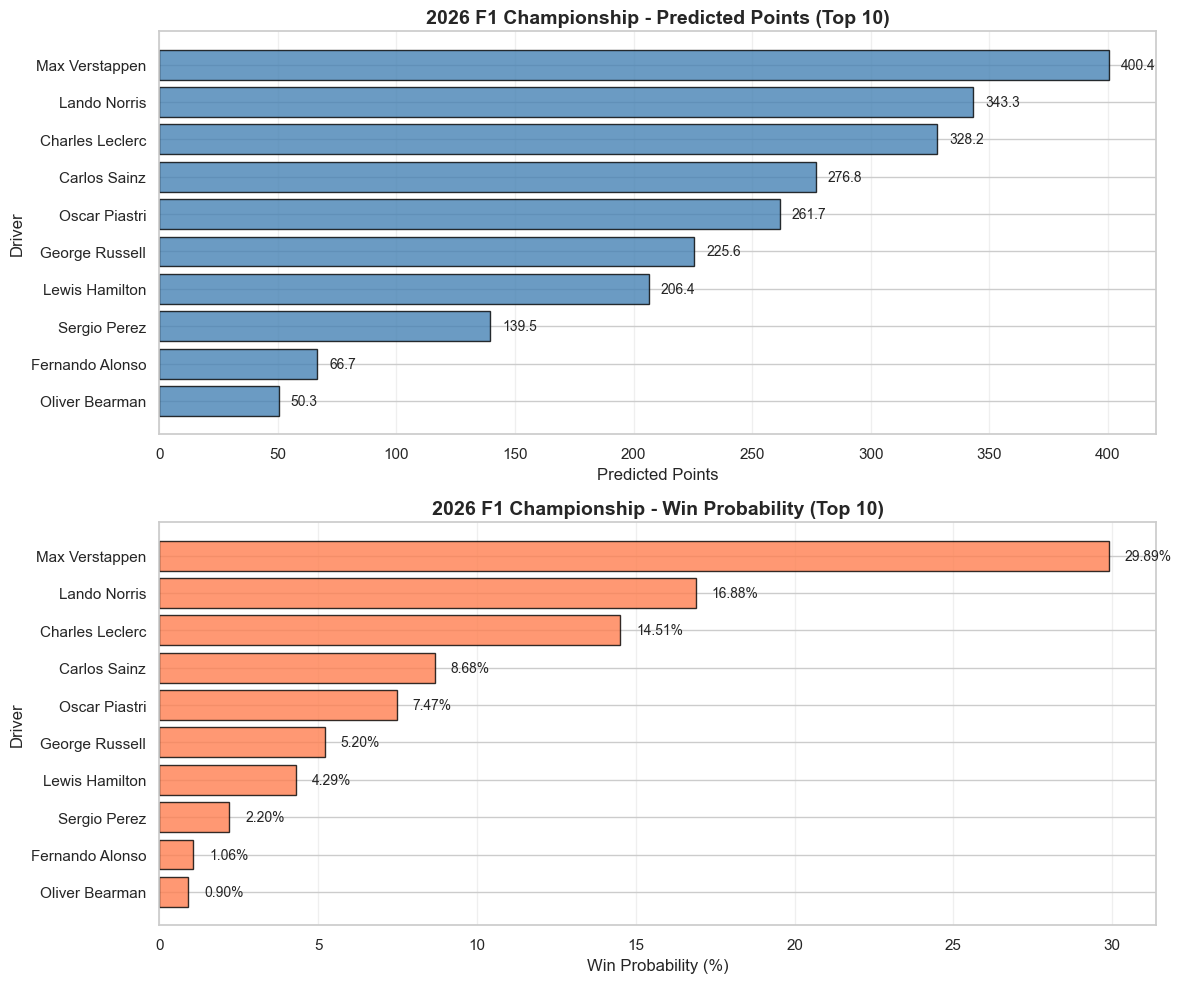

In [71]:
plot_predictions_2026(predictions_df, top_n=10)

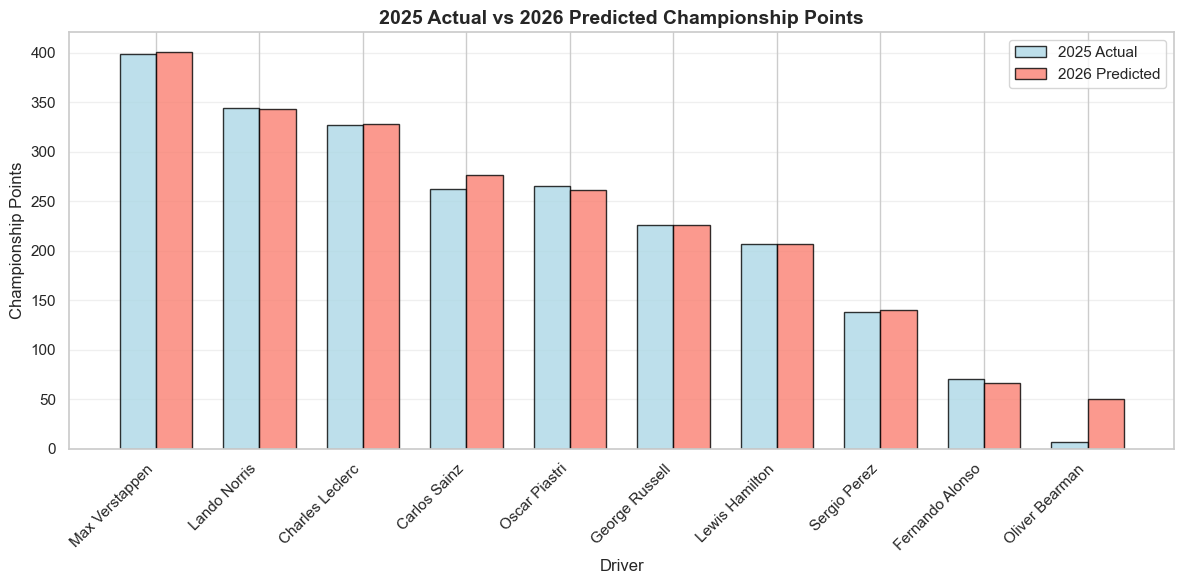

In [72]:
plot_comparison_2025_vs_2026(predictions_df, top_n=10)

In [73]:
# Interactive Plotly charts (if you have plotly installed)
try:
    plot_interactive_predictions(predictions_df)
except ImportError:
    print("⚠ Install plotly for interactive visualizations:  pip install plotly")

In [74]:
top_5 = predictions_df.head(5)

print("\n" + "="*70)
print("DETAILED ANALYSIS - TOP 5 CHAMPIONSHIP CONTENDERS")
print("="*70)

for idx, driver in top_5.iterrows():
    print(f"\n{driver['PredictedPosition']}.  {driver['Driver']} ({driver['Team']})")
    print(f"   {'─'*60}")
    print(f"   Predicted 2026 Points: {driver['Predicted2026Points']:.1f}")
    print(f"   Win Probability: {driver['WinProbability']:.2f}%")
    print(f"   2025 Points: {driver['PrevYearPoints']:.1f}")
    
    # Get historical features
    driver_history = all_features[all_features['Driver'] == driver['Driver']]
    if len(driver_history) > 0:
        latest = driver_history[driver_history['Year'] == latest_year].iloc[0]
        print(f"   2025 Performance:")
        print(f"     • Wins: {int(latest['Wins'])}")
        print(f"     • Podiums: {int(latest['Podiums'])}")
        print(f"     • Avg Finish: {latest['AvgFinish']:.2f}")
        print(f"     • DNF Rate: {latest['DNFRate']:.1%}")


DETAILED ANALYSIS - TOP 5 CHAMPIONSHIP CONTENDERS

1.  Max Verstappen (Red Bull Racing)
   ────────────────────────────────────────────────────────────
   Predicted 2026 Points: 400.4
   Win Probability: 29.89%
   2025 Points: 399.0
   2025 Performance:
     • Wins: 9
     • Podiums: 14
     • Avg Finish: 3.62
     • DNF Rate: 0.0%

2.  Lando Norris (McLaren)
   ────────────────────────────────────────────────────────────
   Predicted 2026 Points: 343.3
   Win Probability: 16.88%
   2025 Points: 344.0
   2025 Performance:
     • Wins: 4
     • Podiums: 13
     • Avg Finish: 4.29
     • DNF Rate: 0.0%

3.  Charles Leclerc (Ferrari)
   ────────────────────────────────────────────────────────────
   Predicted 2026 Points: 328.2
   Win Probability: 14.51%
   2025 Points: 327.0
   2025 Performance:
     • Wins: 3
     • Podiums: 13
     • Avg Finish: 4.54
     • DNF Rate: 0.0%

4.  Carlos Sainz (Ferrari)
   ────────────────────────────────────────────────────────────
   Predicted 2026 Poin

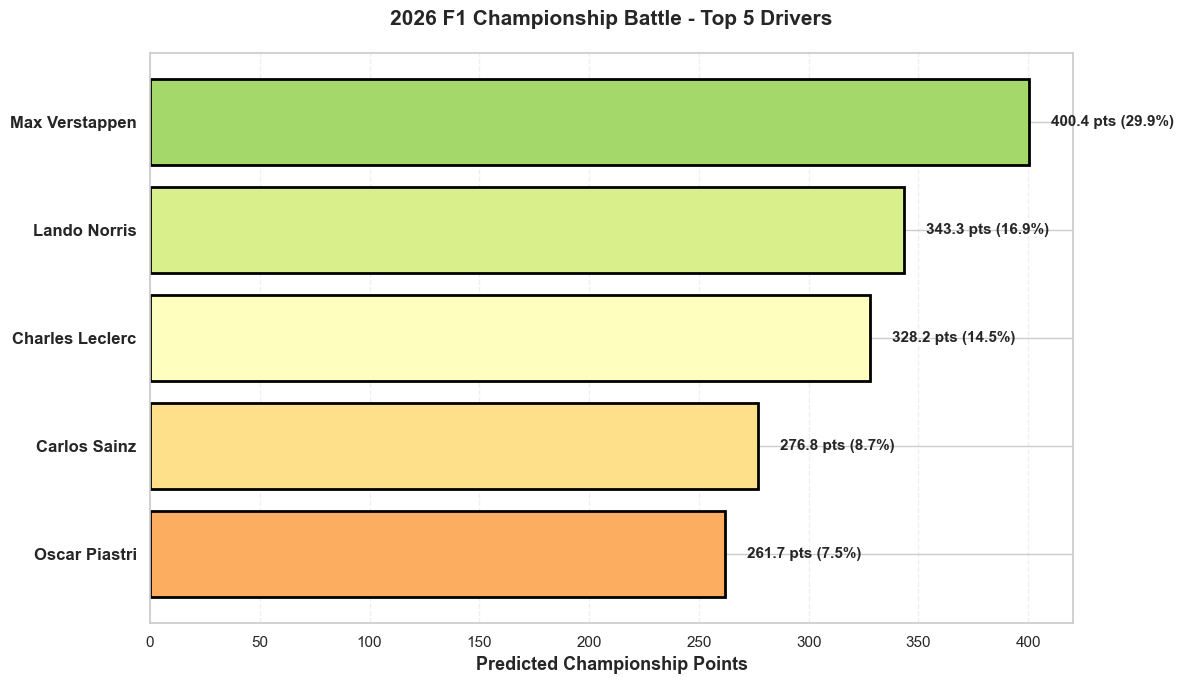

In [75]:
# Top 5 championship battle
top_5 = predictions_df.head(5)

fig, ax = plt.subplots(figsize=(12, 7))

# Create horizontal bar chart
y_pos = np.arange(len(top_5))
bars = ax.barh(y_pos, top_5["Predicted2026Points"], 
               color=plt.cm.RdYlGn(np.linspace(0.7, 0.3, len(top_5))), edgecolor="black", linewidth=2)

# Customize
ax.set_yticks(y_pos)
ax.set_yticklabels(top_5['Driver'], fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Predicted Championship Points', fontsize=13, fontweight='bold')
ax.set_title('2026 F1 Championship Battle - Top 5 Drivers', 
             fontsize=15, fontweight='bold', pad=20)

# Add value labels and win probability
for idx, (bar, points, prob) in enumerate(zip(bars, top_5['Predicted2026Points'], 
                                                top_5['WinProbability'])):
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height()/2,
            f'{points:.1f} pts ({prob:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Championship Point Gaps (Top 10):
   PredictedPosition           Driver  Predicted2026Points  GapToLeader  \
0                  1   Max Verstappen           400.443015     0.000000   
1                  2     Lando Norris           343.307248    57.135767   
2                  3  Charles Leclerc           328.163888    72.279127   
3                  4     Carlos Sainz           276.761863   123.681152   
4                  5    Oscar Piastri           261.708579   138.734436   
5                  6   George Russell           225.574234   174.868781   
6                  7   Lewis Hamilton           206.404567   194.038448   
7                  8     Sergio Perez           139.520911   260.922104   
8                  9  Fernando Alonso            66.670086   333.772929   
9                 10   Oliver Bearman            50.318965   350.124050   

   GapToNext  
0  57.135767  
1  15.143360  
2  51.402025  
3  15.053285  
4  36.134344  
5  19.169667  
6  66.883656  
7  72.850825  
8  1

C:\Users\Paul\AppData\Local\Temp\ipykernel_29928\3652650283.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Paul\AppData\Local\Temp\ipykernel_29928\3652650283.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



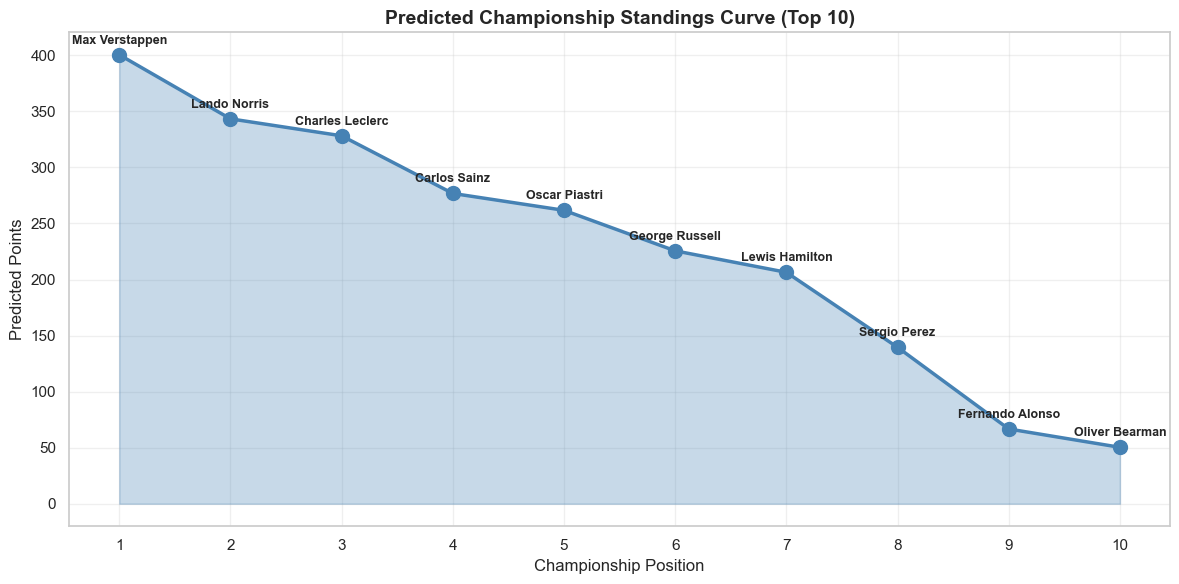

In [76]:
# Analyze point gaps between top drivers
top_10 = predictions_df.head(10)
top_10['GapToLeader'] = top_10['Predicted2026Points']. iloc[0] - top_10['Predicted2026Points']
top_10['GapToNext'] = top_10['Predicted2026Points'].diff(-1).fillna(0).abs()

print("\nChampionship Point Gaps (Top 10):")
print(top_10[['PredictedPosition', 'Driver', 'Predicted2026Points', 
              'GapToLeader', 'GapToNext']])

# Visualize gaps
plt.figure(figsize=(12, 6))
plt.plot(top_10['PredictedPosition'], top_10['Predicted2026Points'], 
         marker='o', linewidth=2.5, markersize=10, color='steelblue')
plt.fill_between(top_10['PredictedPosition'], top_10['Predicted2026Points'], 
                 alpha=0.3, color='steelblue')

# Annotate drivers
for idx, row in top_10.iterrows():
    plt.text(row['PredictedPosition'], row['Predicted2026Points'] + 10,
             row['Driver'], ha='center', fontsize=9, fontweight='bold')

plt.xlabel('Championship Position', fontsize=12)
plt.ylabel('Predicted Points', fontsize=12)
plt.title('Predicted Championship Standings Curve (Top 10)', 
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [77]:
# Save predictions to file
output_dir = "../data/predictions"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "2026_championship_predictions.csv")
predictions_df.to_csv(output_path, index=False)

print(f"✓ Predictions saved to {output_path}")

# Save summary report
report_path = os.path.join(output_dir, "prediction_summary.txt")
with open(report_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write(" "*20 + "2026 F1 CHAMPIONSHIP PREDICTION\n")
    f.write("="*70 + "\n\n")
    f.write(f"Model Test R²: {metrics['test_r2']:.4f}\n")
    f.write("Model Test RMSE: {metrics['test_rmse']:. 2f} points\n\n")
    f.write("TOP 10 PREDICTIONS:\n")
    f.write("-"*70 + "\n")
    f.write(predictions_df.head(10).to_string(index=False))
    f.write("\n\n" + "="*70 + "\n")
    f.write(f"PREDICTED CHAMPION: {predictions_df.iloc[0]['Driver']}\n")
    f.write("="*70 + "\n")

print(f"✓ Summary report saved to {report_path}")

✓ Predictions saved to ../data/predictions\2026_championship_predictions.csv
✓ Summary report saved to ../data/predictions\prediction_summary.txt


In [78]:
create_summary_report(predictions_df, metrics)

                    2026 F1 CHAMPIONSHIP PREDICTION

📊 MODEL PERFORMANCE:
  • Test R² Score: 0.9750
  • Test RMSE: 14.66 points
  • Test MAE: 7.43 points
  • Cross-Validation R² (mean): 0.9935 ± 0.0030

🏆 TOP 5 CHAMPIONSHIP CONTENDERS:

1.  Max Verstappen (Red Bull Racing)
   Predicted Points: 400.4
   Win Probability: 29.89%
   2025 Points: 399.0

2.  Lando Norris (McLaren)
   Predicted Points: 343.3
   Win Probability: 16.88%
   2025 Points: 344.0

3.  Charles Leclerc (Ferrari)
   Predicted Points: 328.2
   Win Probability: 14.51%
   2025 Points: 327.0

4.  Carlos Sainz (Ferrari)
   Predicted Points: 276.8
   Win Probability: 8.68%
   2025 Points: 262.0

5.  Oscar Piastri (McLaren)
   Predicted Points: 261.7
   Win Probability: 7.47%
   2025 Points: 265.0

🎯 PREDICTED 2026 CHAMPION: Max Verstappen


In [79]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Championship contention
top_3_points = predictions_df.head(3)['Predicted2026Points']
points_gap = top_3_points. iloc[0] - top_3_points.iloc[2]

print(f"\n1. Championship Race:")
print(f"   • Top 3 separated by only {points_gap:.1f} points")
print(f"   • Close battle expected between:")
for i in range(3):
    print(f"     - {predictions_df.iloc[i]['Driver']} ({predictions_df.iloc[i]['WinProbability']:.1f}%)")

# Surprise performers
predictions_df['PointsChange'] = predictions_df['Predicted2026Points'] - predictions_df['PrevYearPoints']
improvers = predictions_df. nlargest(3, 'PointsChange')

print(f"\n2. Biggest Improvers:")
for idx, driver in improvers.iterrows():
    print(f"   • {driver['Driver']}: +{driver['PointsChange']:.1f} points")

# Model confidence
print(f"\n3. Model Confidence:")
print("   • R² Score: {metrics['test_r2']:. 4f} (explains {metrics['test_r2']*100:.1f}% of variance)")
print(f"   • Average error: ±{metrics['test_mae']:.1f} points")
print(f"   • Prediction range: {predictions_df['Predicted2026Points'].min():.1f} - {predictions_df['Predicted2026Points'].max():.1f} points")

print("\n" + "="*70)


KEY INSIGHTS

1. Championship Race:
   • Top 3 separated by only 72.3 points
   • Close battle expected between:
     - Max Verstappen (29.9%)
     - Lando Norris (16.9%)
     - Charles Leclerc (14.5%)

2. Biggest Improvers:
   • Oliver Bearman: +43.3 points
   • Carlos Sainz: +14.8 points
   • Liam Lawson: +9.7 points

3. Model Confidence:
   • R² Score: {metrics['test_r2']:. 4f} (explains {metrics['test_r2']*100:.1f}% of variance)
   • Average error: ±7.4 points
   • Prediction range: -1.8 - 400.4 points

